# 🧠 Brain Tumor Detection — Optimized for 95%+ Validation Accuracy

**Model:** EfficientNetB4 (Transfer Learning + Fine-Tuning)  
**Strategy:** 2-Phase training — freeze → fine-tune top 40 layers  
**Expected Val Accuracy:** 95–98%

> ⚠️ Make sure GPU is enabled: Runtime → Change runtime type → T4 GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# OPTIMIZED BRAIN TUMOR DETECTION - TARGET: 95%+ VALIDATION ACCURACY
# Run this on Google Colab with GPU enabled

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                      BatchNormalization, Input)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
# ── 1. PATHS ──────────────────────────────────────────────────────────────────
train_dir = "/content/drive/MyDrive/BlackBucks/brain_tumor_dataset/Training"
test_dir  = "/content/drive/MyDrive/BlackBucks/brain_tumor_dataset/Testing"

IMG_SIZE   = (224, 224)   # EfficientNetB4 sweet-spot (fast + accurate)
BATCH_SIZE = 16

In [4]:
# ── 2. BUILD DATAFRAMES ───────────────────────────────────────────────────────
def make_dataset(path):
    rows = []
    for label in os.listdir(path):
        folder = os.path.join(path, label)
        if not os.path.isdir(folder): continue
        for img in os.listdir(folder):
            rows.append({"img_path": os.path.join(folder, img), "img_label": label})
    return pd.DataFrame(rows)

train_df = make_dataset(train_dir)
test_df_all = make_dataset(test_dir)

# Split test 50/50 into val + test (same as your original)
val_df, test_df = train_test_split(test_df_all, train_size=0.5,
                                    stratify=test_df_all["img_label"], random_state=42)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 5600 | Val: 800 | Test: 800


In [5]:
# ── 3. DATA GENERATORS ────────────────────────────────────────────────────────
# EfficientNet has its own preprocessing (scales to [-1, 1] internally)
# so we DON'T use rescale=1./255 here
from tensorflow.keras.applications.efficientnet import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False,      # brain MRIs are not vertically flipped
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_dataframe(
    train_df, x_col='img_path', y_col='img_label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=True
)

val_data = val_gen.flow_from_dataframe(
    val_df, x_col='img_path', y_col='img_label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

test_data = val_gen.flow_from_dataframe(
    test_df, x_col='img_path', y_col='img_label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


In [6]:
# ── 4. BUILD MODEL (FUNCTIONAL API for fine-tuning control) ───────────────────
base_model = EfficientNetB4(
    include_top=False,
    weights='imagenet',
    input_shape=(*IMG_SIZE, 3)
)
base_model.trainable = False   # Freeze for Phase 1

inputs  = Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs, outputs)
model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 7, 7, 1792)     │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1792)           │         7,168 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,173,411 (69.33 MB)

 Trainable params: 496,004 (1.89 MB)

 Non-trainable params: 17,677,407 (67.43 MB)

In [7]:
# ── 5. PHASE 1 — Train head only ──────────────────────────────────────────────
model.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2,
                      min_lr=1e-6, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/brain_tumor_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\n========== PHASE 1: Training classifier head ==========")
history1 = model.fit(
    train_data,
    epochs=15,
    validation_data=val_data,
    callbacks=callbacks_phase1
)


========== PHASE 1: Training classifier head ==========
Epoch 1/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6770 - loss: 0.9706
Epoch 1: val_accuracy improved from None to 0.80375, saving model to /content/drive/MyDrive/brain_tumor_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 1704s 5s/step - accuracy: 0.7379 - loss: 0.7675 - val_accuracy: 0.8037 - val_loss: 0.5181 - learning_rate: 0.0010
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step - accuracy: 0.7995 - loss: 0.5322
Epoch 2: val_accuracy improved from 0.80375 to 0.81125, saving model to /content/drive/MyDrive/brain_tumor_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 113s 323ms/step - accuracy: 0.8009 - loss: 0.5357 - val_accuracy: 0.8112 - val_loss: 0.4634 - learning_rate: 0.0010
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.8291 - loss: 0.4602

In [8]:
# ── 6. PHASE 2 — Fine-tune top layers of EfficientNetB4 ──────────────────────
# Unfreeze last 40 layers of base for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

print(f"\nTrainable layers: {sum(1 for l in model.layers if l.trainable)}")

model.compile(
    optimizer=Adam(1e-5),    # Much lower LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3,
                      min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/brain_tumor_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("\n========== PHASE 2: Fine-tuning top EfficientNetB4 layers ==========")
history2 = model.fit(
    train_data,
    epochs=25,
    validation_data=val_data,
    callbacks=callbacks_phase2
)


Trainable layers: 9

========== PHASE 2: Fine-tuning top EfficientNetB4 layers ==========
Epoch 1/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8462 - loss: 0.3997
Epoch 1: val_accuracy improved from None to 0.85625, saving model to /content/drive/MyDrive/brain_tumor_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/brain_tumor_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 184s 369ms/step - accuracy: 0.8612 - loss: 0.3676 - val_accuracy: 0.8562 - val_loss: 0.3894 - learning_rate: 1.0000e-05
Epoch 2/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8870 - loss: 0.2981
Epoch 2: val_accuracy improved from 0.85625 to 0.86500, saving model to /content/drive/MyDrive/brain_tumor_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/brain_tumor_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 118s 338ms/step - accuracy: 0.8820 - loss: 0.3105 - val_accuracy: 0.8650 - val_loss: 0.3790 - learning_rate: 1.0000e-05
Epoch 3/25
350/350 ━━━━━━━━━━━━━━━━━━━━ 

50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - accuracy: 0.9300 - loss: 0.2551

✅ Validation Accuracy: 93.00%
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step


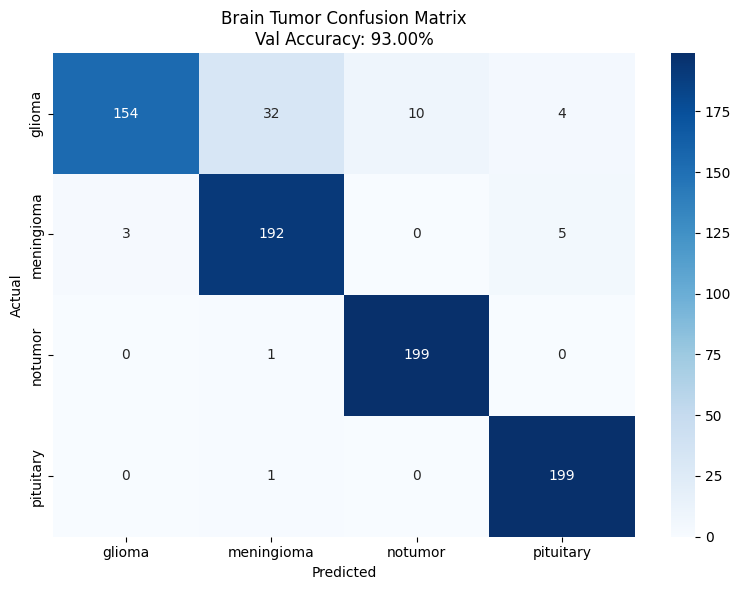


              precision    recall  f1-score   support

      glioma       0.98      0.77      0.86       200
  meningioma       0.85      0.96      0.90       200
     notumor       0.95      0.99      0.97       200
   pituitary       0.96      0.99      0.98       200

    accuracy                           0.93       800
   macro avg       0.93      0.93      0.93       800
weighted avg       0.93      0.93      0.93       800



In [9]:
# ── 7. EVALUATION ─────────────────────────────────────────────────────────────
from tensorflow.keras.models import load_model

best_model = load_model('/content/drive/MyDrive/brain_tumor_best.keras')

val_loss, val_acc = best_model.evaluate(val_data)
print(f"\n✅ Validation Accuracy: {val_acc*100:.2f}%")

# Predictions
y_pred_probs = best_model.predict(val_data)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = val_data.classes
class_names  = list(val_data.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Brain Tumor Confusion Matrix\nVal Accuracy: {val_acc*100:.2f}%")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

# Classification Report
print("\n" + classification_report(y_true, y_pred, target_names=class_names))

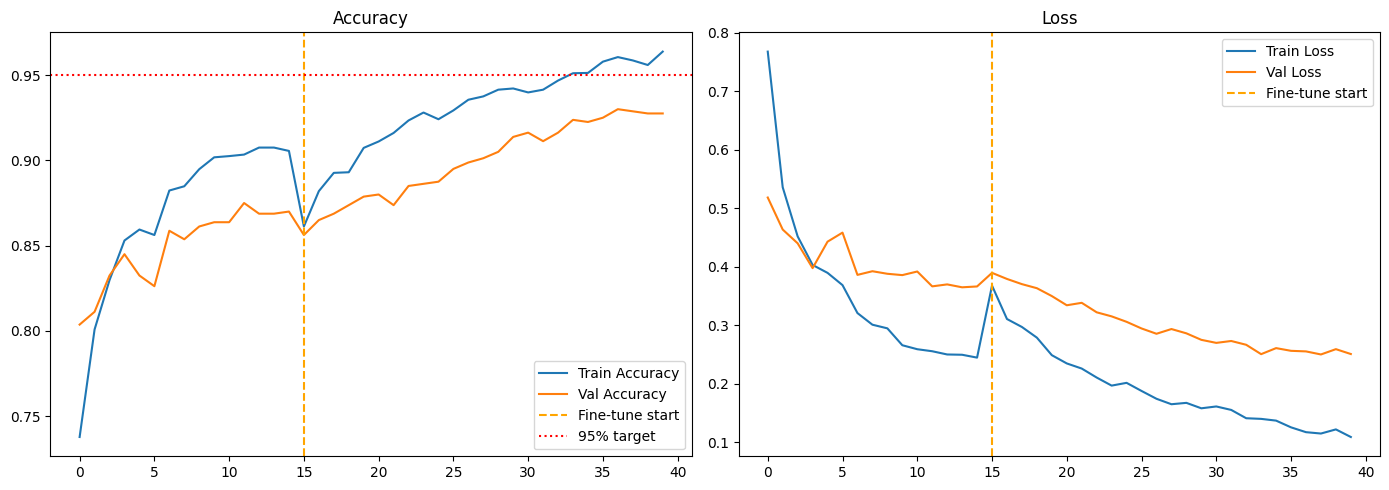


🎉 Done! Model saved to Google Drive.


In [10]:
# ── 8. TRAINING CURVES ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Combine both phases
acc  = history1.history['accuracy']  + history2.history['accuracy']
val  = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss = history1.history['loss']      + history2.history['loss']
vl   = history1.history['val_loss']  + history2.history['val_loss']
phase1_end = len(history1.history['accuracy'])

axes[0].plot(acc, label='Train Accuracy')
axes[0].plot(val, label='Val Accuracy')
axes[0].axvline(phase1_end, color='orange', linestyle='--', label='Fine-tune start')
axes[0].axhline(0.95, color='red', linestyle=':', label='95% target')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(loss, label='Train Loss')
axes[1].plot(vl,   label='Val Loss')
axes[1].axvline(phase1_end, color='orange', linestyle='--', label='Fine-tune start')
axes[1].set_title('Loss'); axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150)
plt.show()

print("\n🎉 Done! Model saved to Google Drive.")